## Toyota cars dataset

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("toyota.csv")

## Columns: 
- Model
- Year
- Price
- Transmission
- Mileage
- Fueltype
- Tax
- Mpg (miles per galon)
- Engine size

In [9]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0
...,...,...,...,...,...,...,...,...,...
6733,IQ,2011,5500,Automatic,30000,Petrol,20,58.9,1.0
6734,Urban Cruiser,2011,4985,Manual,36154,Petrol,125,50.4,1.3
6735,Urban Cruiser,2012,4995,Manual,46000,Diesel,125,57.6,1.4
6736,Urban Cruiser,2011,3995,Manual,60700,Petrol,125,50.4,1.3


## Goal 1: Market value of Toyota car models

In [14]:
df['Price_with_tax'] = df['price'] * (1 + df['tax']/100)

In [16]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Price_with_tax
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0,58400.00
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0,39187.75
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0,51092.70
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0,47495.00
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0,42870.10
...,...,...,...,...,...,...,...,...,...,...
6733,IQ,2011,5500,Automatic,30000,Petrol,20,58.9,1.0,6600.00
6734,Urban Cruiser,2011,4985,Manual,36154,Petrol,125,50.4,1.3,11216.25
6735,Urban Cruiser,2012,4995,Manual,46000,Diesel,125,57.6,1.4,11238.75
6736,Urban Cruiser,2011,3995,Manual,60700,Petrol,125,50.4,1.3,8988.75


In [18]:
Market_value = df[['model', 'Price_with_tax']]

In [20]:
Market_value

,model,Price_with_tax
0,GT86,58400.00
1,GT86,39187.75
2,GT86,51092.70
3,GT86,47495.00
4,GT86,42870.10
...,...,...
6733,IQ,6600.00
6734,Urban Cruiser,11216.25
6735,Urban Cruiser,11238.75
6736,Urban Cruiser,8988.75


In [30]:
Market_vehicles = Market_value.groupby('model')['Price_with_tax'].sum().reset_index()

In [32]:
Market_vehicles

,model,Price_with_tax
0,Auris,12788379.35
1,Avensis,2356155.70
2,Aygo,31075990.05
3,C-HR,21015900.95
4,Camry,697050.60
5,Corolla,13346737.35
6,GT86,3937899.05
7,Hilux,6680501.15
8,IQ,38561.00
9,Land Cruiser,5688927.45


In [34]:
Market_vehicles_sort = Market_vehicles.sort_values(by = 'Price_with_tax', ascending = False)

In [36]:
Market_vehicles_sort

,model,Price_with_tax
17,Yaris,42540199.60
2,Aygo,31075990.05
3,C-HR,21015900.95
12,RAV4,17633111.75
5,Corolla,13346737.35
0,Auris,12788379.35
11,Prius,7095046.60
7,Hilux,6680501.15
9,Land Cruiser,5688927.45
6,GT86,3937899.05


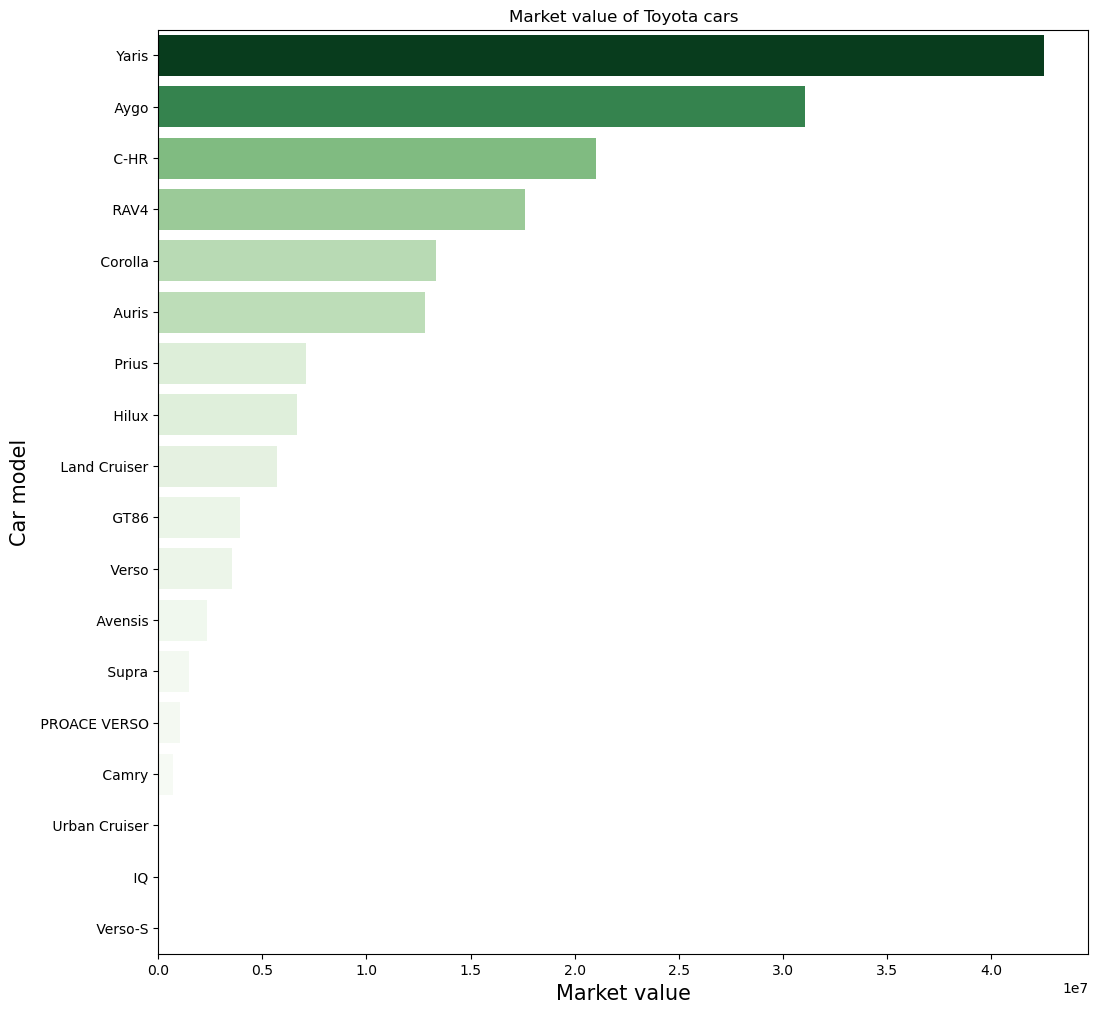

In [54]:
plt.figure(figsize = (12, 12))
sns.barplot(data = Market_vehicles_sort, y = Market_vehicles_sort['model'], x = Market_vehicles_sort['Price_with_tax'], 
            palette = 'Greens', hue = Market_vehicles_sort['Price_with_tax'])
plt.xlabel('Market value', size = 15)
plt.ylabel('Car model', size = 15)
plt.legend([], [], frameon = False)
plt.title('Market value of Toyota cars')
plt.show()

## Conclusions:
- Toyota Yaris has the highest market value, which shows high value and high demand.
- Followd by: Aygo, C-HR, RAV4, they are popular with high to mid range buyers.
- Followed by: Corolla, Auris, Prius, Hillux, Land cruiser, this shows that buyers are willing to buy vehicles that offer high durability and reliability, rather than value.
- Followed by:  GT86, Verso, Avensis, Supra, Proace verso, Camry, Urban cruiser, IQ, Verso-s, these models are niche therefore less value therefore less demand.

## Goal 2: Average value of Toyota cars i.e. Best selling Toyota car

In [58]:
Market_value = df[['model', 'Price_with_tax']]

In [60]:
Market_value

,model,Price_with_tax
0,GT86,58400.00
1,GT86,39187.75
2,GT86,51092.70
3,GT86,47495.00
4,GT86,42870.10
...,...,...
6733,IQ,6600.00
6734,Urban Cruiser,11216.25
6735,Urban Cruiser,11238.75
6736,Urban Cruiser,8988.75


In [64]:
Best_selling = Market_value.groupby('model')['Price_with_tax'].mean().reset_index()

In [66]:
Best_selling

,model,Price_with_tax
0,Auris,17961.206952
1,Avensis,20488.310435
2,Aygo,15847.011754
3,C-HR,43874.532255
4,Camry,63368.236364
5,Corolla,49987.780337
6,GT86,53943.822603
7,Hilux,77680.245930
8,IQ,4820.125000
9,Land Cruiser,111547.597059


In [68]:
Best_selling_sort = Best_selling.sort_values(by = 'Price_with_tax', ascending = False)

In [70]:
Best_selling_sort

,model,Price_with_tax
13,Supra,124565.429167
9,Land Cruiser,111547.597059
7,Hilux,77680.245930
10,PROACE VERSO,70266.490000
4,Camry,63368.236364
6,GT86,53943.822603
5,Corolla,49987.780337
3,C-HR,43874.532255
12,RAV4,37279.306025
15,Verso,30996.083333


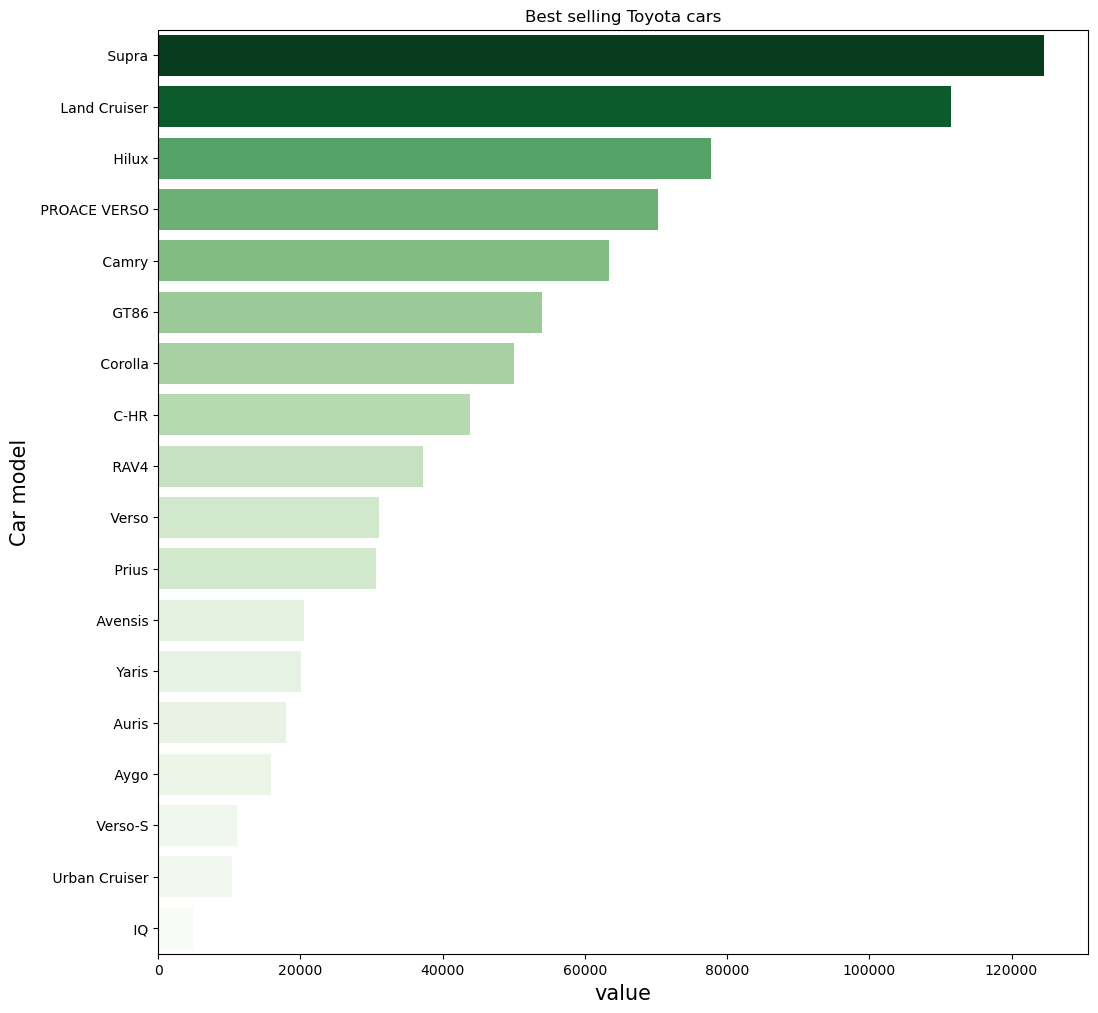

In [72]:
plt.figure(figsize = (12, 12))
sns.barplot(data = Best_selling_sort, y = Best_selling_sort['model'], x = Best_selling_sort['Price_with_tax'], 
            palette = 'Greens', hue = Best_selling_sort['Price_with_tax'])
plt.xlabel('value', size = 15)
plt.ylabel('Car model', size = 15)
plt.legend([], [], frameon = False)
plt.title('Best selling Toyota cars')
plt.show()

## Insights:
## Best sales:
- Supra and Land cruiser are the best cars in terms of sales performance.
## Slightly high sales:
- Hillux, Proace verso, Camry.
## Medium sales:
- GT86, Corolla, C-HR, RAV4.
## Low sales:
- Verso, Prius, Avensis, Yaris, Auris, Aygo, Verso-S, Urban Cruiser, IQ.
## Conclusions:
- Sports and Luxury cars make the best sales, their supply is low therefore high demand therefore high value, they offer speed and coolness, they are marketed to young people especially rich ones.
- Economic and regular cars make the lowest sales, their supply is high therefore low demand therefore less value, they are marketed to middle class individuals especially to couples and families, they offer practicality than coolness.